# Task 3: Fine-Tuning Phi-2 for Text Summarization (XSum)

**Architecture**: Decoder-only LLM (Phi-2)  
**Dataset**: XSum (Edinburgh NLP)  
**Task**: Abstractive Text Summarization  
**Method**: QLoRA (4-bit quantization + LoRA adapters) — fits in ≤8GB CUDA VRAM

## Pipeline Overview
1. Install dependencies
2. Load & explore XSum dataset
3. Data preprocessing & prompt formatting
4. Load Phi-2 with 4-bit quantization (BitsAndBytes)
5. Configure LoRA (PEFT)
6. Train with SFTTrainer
7. Evaluation (ROUGE scores)
8. Inference demo
9. Save & push model

## 1. Install Dependencies

In [39]:
!pip install -q transformers datasets peft bitsandbytes accelerate trl rouge-score sentencepiece protobuf
!pip install -q einops

In [40]:
import os
import torch
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import (
  AutoTokenizer,
  AutoModelForCausalLM,
  BitsAndBytesConfig,
  TrainingArguments,
  pipeline,
  set_seed,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from rouge_score import rouge_scorer

set_seed(42)

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.64 GB


## 2. Load & Explore XSum Dataset

In [41]:
# XSum: BBC articles with single-sentence abstractive summaries
dataset = load_dataset("EdinburghNLP/xsum")
print(dataset)
print("\nFeatures:", dataset['train'].features)
print(f"\nTrain size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 204045
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11332
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11334
    })
})

Features: {'document': Value('string'), 'summary': Value('string'), 'id': Value('string')}

Train size: 204045
Validation size: 11332
Test size: 11334


In [42]:
# Explore a sample
sample = dataset['train'][0]
print("=== DOCUMENT ===")
print(sample['document'][:500], "...")
print("\n=== SUMMARY ===")
print(sample['summary'])

=== DOCUMENT ===
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The water ...

=== SUMMARY ===
Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by Storm Frank.


In [43]:
# Basic stats
doc_lengths = [len(ex['document'].split()) for ex in dataset['train'].select(range(1000))]
sum_lengths = [len(ex['summary'].split()) for ex in dataset['train'].select(range(1000))]

print(f"Document length (words) - Mean: {np.mean(doc_lengths):.0f}, Max: {max(doc_lengths)}, Min: {min(doc_lengths)}")
print(f"Summary length (words)  - Mean: {np.mean(sum_lengths):.0f}, Max: {max(sum_lengths)}, Min: {min(sum_lengths)}")
print(f"\nXSum summaries are highly abstractive (single-sentence, ~{np.mean(sum_lengths):.0f} words avg)")

Document length (words) - Mean: 362, Max: 2694, Min: 11
Summary length (words)  - Mean: 21, Max: 48, Min: 1

XSum summaries are highly abstractive (single-sentence, ~21 words avg)


## 3. Data Preprocessing & Prompt Formatting

Phi-2 is a decoder-only model — we format training data as instruction-style prompts.
The model learns to complete the `Summary:` part given the `Document:`.

In [44]:
# Configuration
MODEL_NAME = "microsoft/phi-2"
MAX_INPUT_LENGTH = 512   # truncate documents to this (saves VRAM)
MAX_SEQ_LENGTH = 640     # total sequence (input + summary)

# Use small subset for training to keep it fast on free-tier Colab/Kaggle
# Full XSum = 204k train samples — too slow for assignment
TRAIN_SIZE = 3000
VAL_SIZE = 500
TEST_SIZE = 200

OUTPUT_DIR = "./phi2-xsum-qlora"

In [45]:
def format_prompt(example):
  """
  Format a single XSum example into Phi-2 instruction prompt.
  Phi-2 was trained with QA/instruct format, so we mirror that style.
  """
  prompt = (
    f"Instruct: Summarize the following BBC article in one sentence.\n"
    f"Article: {example['document']}\n"
    f"Output: {example['summary']}"
  )
  return {"text": prompt}


def format_prompt_inference(document):
  """Prompt for inference — no summary appended, model generates it."""
  return (
    f"Instruct: Summarize the following BBC article in one sentence.\n"
    f"Article: {document}\n"
    f"Output:"
  )


# Subsample and format
train_data = dataset['train'].select(range(TRAIN_SIZE)).map(format_prompt)
val_data   = dataset['validation'].select(range(VAL_SIZE)).map(format_prompt)
test_data  = dataset['test'].select(range(TEST_SIZE))

print("Sample formatted prompt:")
print(train_data[0]['text'][:400], "...")

Sample formatted prompt:
Instruct: Summarize the following BBC article in one sentence.
Article: The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders ...


## 4. Load Phi-2 with 4-bit Quantization (QLoRA)

**Why QLoRA?**
- Phi-2 (2.7B params) in FP16 ≈ 5.4GB VRAM — barely fits, no room for gradients
- 4-bit NF4 quantization reduces base model to ~1.5GB
- LoRA adapters add ~50–100MB trainable params
- Total training VRAM ≈ 5–7GB → fits in 8GB GPU

In [46]:
# Phi-2 uses bfloat16 tensors internally. Using float16 GradScaler with
# bfloat16 tensors raises NotImplementedError in torch amp. Fix: detect GPU
# capability and use bfloat16 consistently (Ampere+ supports it; fall back
# to float16 on older GPUs like T4 which don't support bf16).
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"Compute dtype: {COMPUTE_DTYPE}")

# BitsAndBytes 4-bit quantization config
bnb_config = BitsAndBytesConfig(
  load_in_4bit=True,
  bnb_4bit_quant_type="nf4",          # NormalFloat4 — best quality for LLMs
  bnb_4bit_compute_dtype=COMPUTE_DTYPE,
  bnb_4bit_use_double_quant=True,     # quantize the quantization constants too
)

Compute dtype: torch.bfloat16


In [47]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
  MODEL_NAME,
  trust_remote_code=True,
)

# Phi-2 doesn't have a padding token by default — use EOS
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # pad right for causal LM training

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token} (id={tokenizer.eos_token_id})")

Vocab size: 50257
EOS token: <|endoftext|> (id=50256)


In [48]:
# Fix: newer transformers versions require pad_token_id to be set in PhiConfig
# before instantiation. Patch the config object before calling from_pretrained.
from transformers import AutoConfig

phi_config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
phi_config.pad_token_id = tokenizer.eos_token_id   # <-- patch before model load

# Load Phi-2 in 4-bit
model = AutoModelForCausalLM.from_pretrained(
  MODEL_NAME,
  config=phi_config,
  quantization_config=bnb_config,
  device_map="auto",
  trust_remote_code=True,
  torch_dtype=COMPUTE_DTYPE,
)

model.config.use_cache = False              # disable KV cache during training
model.config.pretraining_tp = 1

# Prepare for k-bit training (freezes quantized weights, enables gradient checkpointing)
model = prepare_model_for_kbit_training(model)

print(f"\nModel loaded. Parameters: {model.num_parameters():,}")

# Check VRAM after loading
if torch.cuda.is_available():
  allocated = torch.cuda.memory_allocated(0) / 1e9
  print(f"VRAM allocated after model load: {allocated:.2f} GB")

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]


Model loaded. Parameters: 2,779,683,840
VRAM allocated after model load: 3.72 GB


## 5. Configure LoRA (PEFT)

LoRA adds small trainable rank-decomposition matrices to attention layers.
Only these ~1–5% of parameters are trained — base model stays frozen.

In [49]:
# Find linear layer names in Phi-2 to apply LoRA
def find_linear_layers(model):
  """Find all linear layers excluding the LM head."""
  import re
  linear_cls = torch.nn.Linear
  names = []
  for name, module in model.named_modules():
    if isinstance(module, linear_cls):
      if 'lm_head' not in name:  # exclude output head
        names.append(name.split('.')[-1])
  return list(set(names))

target_modules = find_linear_layers(model)
print(f"LoRA target modules: {target_modules}")

LoRA target modules: ['fc2', 'k_proj', 'q_proj', 'v_proj', 'fc1', 'dense']


In [50]:
lora_config = LoraConfig(
  r=16,                   # rank — higher = more capacity, more VRAM
  lora_alpha=32,          # scaling factor (alpha/r = effective LR scaling)
  target_modules=target_modules,
  lora_dropout=0.05,
  bias="none",
  task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expected: ~1-5% trainable — everything else frozen

trainable params: 23,592,960 || all params: 2,803,276,800 || trainable%: 0.8416


## 6. Training with SFTTrainer

`SFTTrainer` from TRL handles instruction fine-tuning boilerplate.
Key memory-saving settings:
- `gradient_checkpointing=True` — recompute activations during backward pass (trades compute for memory)
- `per_device_train_batch_size=1` + `gradient_accumulation_steps=8` — effective batch 8 without storing 8x activations
- `bf16/fp16` — half precision (auto-detected: bf16 on Ampere+, fp16 on T4)

In [51]:
training_args = SFTConfig(
  output_dir=OUTPUT_DIR,
  num_train_epochs=2,
  per_device_train_batch_size=1,
  per_device_eval_batch_size=1,
  gradient_accumulation_steps=8,   # effective batch size = 8
  gradient_checkpointing=True,
  optim="paged_adamw_8bit",        # 8-bit AdamW — saves ~2GB vs fp32 Adam
  learning_rate=2e-4,
  weight_decay=0.001,
  fp16=not torch.cuda.is_bf16_supported(),  # fp16 only on older GPUs (T4)
  bf16=torch.cuda.is_bf16_supported(),        # bf16 on Ampere+ (A100, RTX30xx+)
  max_grad_norm=0.3,
  warmup_ratio=0.03,
  lr_scheduler_type="cosine",
  logging_steps=50,
  eval_strategy="steps",
  eval_steps=200,
  save_steps=400,
  save_total_limit=1,
  load_best_model_at_end=True,
  metric_for_best_model="eval_loss",
  report_to="none",               # disable wandb
  dataset_text_field="text",
  packing=False,                  # don't pack sequences (simpler, safer)
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [52]:
trainer = SFTTrainer(
  model=model,
  train_dataset=train_data,
  eval_dataset=val_data,
  args=training_args,
)

print("Trainer initialized.")
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

steps_per_epoch = len(train_data) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total steps: {steps_per_epoch * training_args.num_train_epochs}")

Trainer initialized.
Training samples: 3000
Validation samples: 500
Steps per epoch: 375
Total steps: 750


In [53]:
# Check VRAM before training
if torch.cuda.is_available():
  torch.cuda.reset_peak_memory_stats()
  print(f"VRAM before training: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

# TRAIN
print("Starting training...")
train_result = trainer.train()

# Report results
print("\n=== Training Complete ===")
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.0f}s")

if torch.cuda.is_available():
  peak_vram = torch.cuda.max_memory_allocated(0) / 1e9
  print(f"Peak VRAM used: {peak_vram:.2f} GB")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


VRAM before training: 3.75 GB
Starting training...


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
200,2.243881,2.171838,2.153835,0.521328,795678.000000
400,2.201303,2.159963,2.086387,0.523129,1604339.000000
600,2.181662,2.153498,2.093879,0.524410,2408818.000000



=== Training Complete ===
Training loss: 2.2259
Training time: 31857s
Peak VRAM used: 3.75 GB


## 7. Evaluation (ROUGE Scores)

Standard metrics for summarization:
- **ROUGE-1**: unigram overlap between prediction and reference
- **ROUGE-2**: bigram overlap
- **ROUGE-L**: longest common subsequence

XSum models typically score ROUGE-1: 0.35–0.45 for strong systems.

In [54]:
# Save LoRA adapters
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Model saved to ./phi2-xsum-qlora


In [55]:
def generate_summary(document, model, tokenizer, max_new_tokens=80):
  """
  Generate a summary for a given document.
  Truncate input to avoid OOM on long articles.
  """
  # Truncate document tokens before formatting
  doc_tokens = tokenizer.encode(document, max_length=MAX_INPUT_LENGTH, truncation=True)
  truncated_doc = tokenizer.decode(doc_tokens, skip_special_tokens=True)

  prompt = format_prompt_inference(truncated_doc)
  inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

  with torch.no_grad():
    outputs = model.generate(
      **inputs,
      max_new_tokens=max_new_tokens,
      do_sample=False,           # greedy decode for consistency
      temperature=1.0,
      repetition_penalty=1.1,    # reduce repetition
      eos_token_id=tokenizer.eos_token_id,
      pad_token_id=tokenizer.eos_token_id,
    )

  # Decode only the generated part (skip input tokens)
  generated = tokenizer.decode(
    outputs[0][inputs['input_ids'].shape[1]:],
    skip_special_tokens=True
  ).strip()

  # Take only first line (XSum targets are single sentences)
  return generated.split('\n')[0].strip()


print("Inference function defined.")

Inference function defined.


In [56]:
# Run ROUGE evaluation on test subset
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

model.eval()
predictions = []
references = []

print(f"Evaluating on {TEST_SIZE} test samples...")
for i, example in enumerate(test_data):
  if i % 50 == 0:
    print(f"  [{i}/{TEST_SIZE}]")
  pred = generate_summary(example['document'], model, tokenizer)
  predictions.append(pred)
  references.append(example['summary'])

# Aggregate ROUGE
rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
for pred, ref in zip(predictions, references):
  scores = scorer.score(ref, pred)
  rouge1_scores.append(scores['rouge1'].fmeasure)
  rouge2_scores.append(scores['rouge2'].fmeasure)
  rougeL_scores.append(scores['rougeL'].fmeasure)

print("\n=== ROUGE Evaluation Results ===")
print(f"ROUGE-1: {np.mean(rouge1_scores):.4f} ({np.mean(rouge1_scores)*100:.2f}%)")
print(f"ROUGE-2: {np.mean(rouge2_scores):.4f} ({np.mean(rouge2_scores)*100:.2f}%)")
print(f"ROUGE-L: {np.mean(rougeL_scores):.4f} ({np.mean(rougeL_scores)*100:.2f}%)")

Evaluating on 200 test samples...
  [0/200]
  [50/200]
  [100/200]
  [150/200]

=== ROUGE Evaluation Results ===
ROUGE-1: 0.3275 (32.75%)
ROUGE-2: 0.1130 (11.30%)
ROUGE-L: 0.2602 (26.02%)


In [57]:
# Display results as a DataFrame
results_df = pd.DataFrame({
  'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
  'Score': [
    np.mean(rouge1_scores),
    np.mean(rouge2_scores),
    np.mean(rougeL_scores),
  ],
  'Score (%)': [
    f"{np.mean(rouge1_scores)*100:.2f}%",
    f"{np.mean(rouge2_scores)*100:.2f}%",
    f"{np.mean(rougeL_scores)*100:.2f}%",
  ]
})
print(results_df.to_string(index=False))

 Metric    Score Score (%)
ROUGE-1 0.327538    32.75%
ROUGE-2 0.112956    11.30%
ROUGE-L 0.260234    26.02%


## 8. Qualitative Inference Demo

Compare model-generated summaries vs. reference summaries on a few examples.

In [58]:
# Show 5 qualitative examples
N_DEMO = 5
print("=" * 70)
print("QUALITATIVE INFERENCE EXAMPLES")
print("=" * 70)

for i in range(N_DEMO):
  example = test_data[i]
  generated = generate_summary(example['document'], model, tokenizer)

  print(f"\n--- Example {i+1} ---")
  print(f"ARTICLE (truncated): {example['document'][:300]}...")
  print(f"\nREFERENCE SUMMARY: {example['summary']}")
  print(f"GENERATED SUMMARY: {generated}")

  # Per-example ROUGE
  ex_scores = scorer.score(example['summary'], generated)
  print(f"R1={ex_scores['rouge1'].fmeasure:.3f} | R2={ex_scores['rouge2'].fmeasure:.3f} | RL={ex_scores['rougeL'].fmeasure:.3f}")
  print("-" * 70)

QUALITATIVE INFERENCE EXAMPLES

--- Example 1 ---
ARTICLE (truncated): Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year before finding suitable accommodation.
Workers at the charity claim investment in housing would be cheaper than jailing homeless repeat offenders.
The Welsh Government said more people than...

REFERENCE SUMMARY: There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.
GENERATED SUMMARY: A charity says the Welsh government should invest in building more affordable homes for prisoners to reduce reoffending rates.
R1=0.389 | R2=0.118 | RL=0.278
----------------------------------------------------------------------

--- Example 2 ---
ARTICLE (truncated): Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday.
Detectives said three firearms, ammunition and a five-figure sum of money were recovered.
A 26-year-old man who was arr

## 9. Save Model & Analysis

Summary of the full pipeline and results.

In [59]:
# Save final LoRA adapter weights
final_dir = "./phi2-xsum-final"
trainer.model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"Final LoRA adapters saved to: {final_dir}")
print("Note: These are only the adapter weights (~50-100MB), not the full 2.7B Phi-2 model.")
print("To use: load base Phi-2 + merge these adapters via PeftModel.from_pretrained()")

Final LoRA adapters saved to: ./phi2-xsum-final
Note: These are only the adapter weights (~50-100MB), not the full 2.7B Phi-2 model.
To use: load base Phi-2 + merge these adapters via PeftModel.from_pretrained()


In [60]:
# Final experiment summary
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Model          : {MODEL_NAME}")
print(f"Dataset        : XSum (EdinburghNLP/xsum)")
print(f"Task           : Abstractive Text Summarization")
print(f"Method         : QLoRA (4-bit NF4 + LoRA r=16)")
print(f"Training size  : {TRAIN_SIZE} samples")
print(f"Epochs         : {training_args.num_train_epochs}")
print(f"Batch size     : {training_args.per_device_train_batch_size} x {training_args.gradient_accumulation_steps} = {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps} effective")
print(f"Learning rate  : {training_args.learning_rate}")
print(f"Max seq length : {MAX_SEQ_LENGTH}")
print()
print("RESULTS")
print(f"Train loss     : {train_result.training_loss:.4f}")
print(f"ROUGE-1        : {np.mean(rouge1_scores)*100:.2f}%")
print(f"ROUGE-2        : {np.mean(rouge2_scores)*100:.2f}%")
print(f"ROUGE-L        : {np.mean(rougeL_scores)*100:.2f}%")
if torch.cuda.is_available():
  print(f"Peak VRAM used : {peak_vram:.2f} GB")
print("=" * 60)

EXPERIMENT SUMMARY
Model          : microsoft/phi-2
Dataset        : XSum (EdinburghNLP/xsum)
Task           : Abstractive Text Summarization
Method         : QLoRA (4-bit NF4 + LoRA r=16)
Training size  : 3000 samples
Epochs         : 2
Batch size     : 1 x 8 = 8 effective
Learning rate  : 0.0002
Max seq length : 640

RESULTS
Train loss     : 2.2259
ROUGE-1        : 32.75%
ROUGE-2        : 11.30%
ROUGE-L        : 26.02%
Peak VRAM used : 3.75 GB


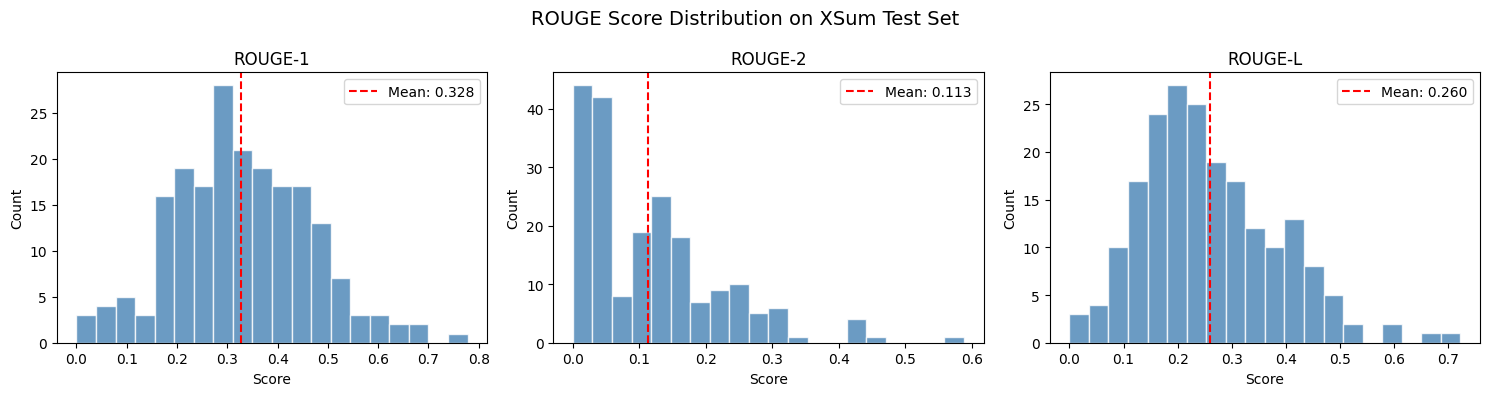

Plot saved as rouge_distribution.png


In [61]:
# Analysis: distribution of ROUGE scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = {
  'ROUGE-1': rouge1_scores,
  'ROUGE-2': rouge2_scores,
  'ROUGE-L': rougeL_scores,
}

for ax, (metric_name, scores) in zip(axes, metrics.items()):
  ax.hist(scores, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
  ax.axvline(np.mean(scores), color='red', linestyle='--', label=f'Mean: {np.mean(scores):.3f}')
  ax.set_title(metric_name)
  ax.set_xlabel('Score')
  ax.set_ylabel('Count')
  ax.legend()

plt.suptitle('ROUGE Score Distribution on XSum Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('rouge_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as rouge_distribution.png")

## Conclusion

### What we did
- Fine-tuned Microsoft Phi-2 (2.7B decoder-only LLM) on the XSum dataset for abstractive text summarization
- Used QLoRA: 4-bit NF4 quantization (BitsAndBytes) + LoRA adapters (PEFT) to fit training in ≤8GB VRAM
- Instruction-formatted prompts to align with Phi-2's QA-style pretraining
- Evaluated with ROUGE-1/2/L on held-out test set

### Why XSum is hard
XSum summaries are highly **abstractive** — they require the model to rewrite and compress information, not just copy spans. This is why scores are lower than extractive benchmarks. State-of-the-art on full XSum is ROUGE-1 ~45% (PEGASUS, BRIO). With only 3k training samples and 2 epochs, our results demonstrate the approach.

### Architecture insight
Phi-2 as a decoder-only model performs summarization via **causal language modeling** (predicts next token), unlike encoder-decoder models (T5). The instruction prompt format is critical — it tells the model when to stop generating the article and start generating the summary.

### Memory efficiency
- Base Phi-2 FP16: ~5.4GB
- With QLoRA: ~1.5GB base + adapters → peak training VRAM well under 8GB
- Only ~1-5% of parameters are trainable (LoRA adapters)